# Entrenamiento de Modelos de Salud Mental: Ansiedad y Estrés

Este notebook unifica el pipeline de aprendizaje automático para entrenar y evaluar modelos predictivos de **Ansiedad** y **Estrés** a partir de datos de cuestionarios clínicos.

## 1. Importación de Librerías y Configuración

In [21]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Configurar estilo de los graficos
plt.style.use('ggplot')
print("Librerias cargadas exitosamente.")

Librerias cargadas exitosamente.


In [22]:
def split_train_val_test(X, y, train_size=0.8, val_size=0.1, test_size=0.1, random_state=3):
    if abs(train_size + val_size + test_size - 1.0) > 1e-6:
        raise ValueError('train/val/test sizes must sum to 1.0')
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(1.0 - train_size), random_state=random_state, stratify=y
    )
    val_ratio = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1.0 - val_ratio), random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def report_split_metrics(name, y_true, y_pred, labels, cmap):
    print(f"\n--- Reporte de Clasificacion ({name}) ---")
    print(classification_report(y_true, y_pred, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=cmap, ax=ax)
    plt.title(f"Matriz de Confusion - {name}")
    plt.grid(False)
    plt.show()

## 2. Modelo de Predicción de Ansiedad (Regresión Logística)

Cargamos los datos de `Data_ansiedad.xlsx`, exploramos la distribución y entrenamos un modelo de Regresión Logística regularizado mediante búsqueda de hiperparámetros.

Dimensiones del dataset de Ansiedad: (204, 12)
Valores nulos en el dataset: 0

Distribución de Clases (Nivel de Ansiedad):
NIVEL_ANSIEDAD
SIN ANSIEDAD         75
ANSIEDAD LEVE        67
ANSIEDAD MODERADA    45
ANSIEDAD GRAVE       17
Name: count, dtype: int64


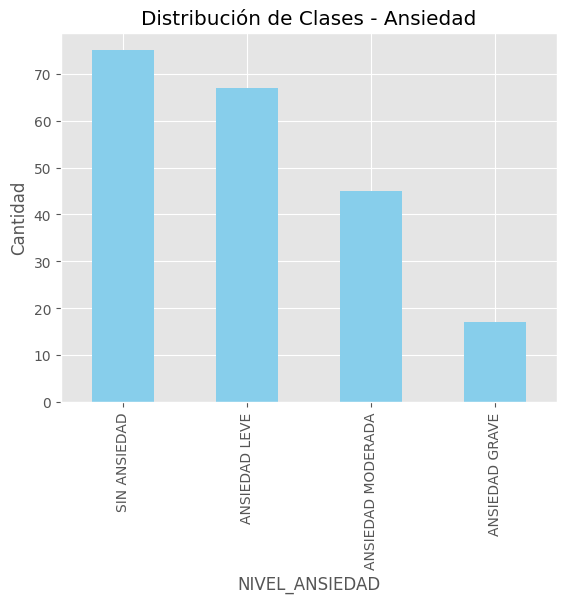

In [ ]:
# Cargar datos
data_ans = pd.read_excel('Data_ansiedad.xlsx')
print(f"Dimensiones del dataset de Ansiedad: {data_ans.shape}")
print(f"Valores nulos en el dataset: {data_ans.isnull().sum().sum()}")

# Distribución del nivel de ansiedad
print("\nDistribución de Clases (Nivel de Ansiedad):")
print(data_ans['NIVEL_ANSIEDAD'].value_counts())
data_ans['NIVEL_ANSIEDAD'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución de Clases - Ansiedad')
plt.ylabel('Cantidad')
plt.show()

In [24]:
# Preparacion de datos
# Usamos las 6 preguntas clinicas (P_A1 a P_A6)
# Convertimos a numpy standard usando .to_numpy() para evitar incompatibilidades con arrays Arrow
X_ans = data_ans[['P_A1','P_A2','P_A3','P_A4','P_A5','P_A6']].to_numpy()
y_ans = data_ans['NIVEL_ANSIEDAD'].to_numpy(dtype=str)

# Particion train/val/test estratificada: 80/10/10
X_train_ans, X_val_ans, X_test_ans, y_train_ans, y_val_ans, y_test_ans = split_train_val_test(
    X_ans, y_ans, train_size=0.8, val_size=0.1, test_size=0.1, random_state=3
 )

print(f"Entrenamiento: {X_train_ans.shape}, Validacion: {X_val_ans.shape}, Prueba: {X_test_ans.shape}")

# Pipeline que encapsula StandardScaler y LogisticRegression para prevenir data leakage
pipeline_ans = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Rejilla de hiperparametros (C es el inverso de la fuerza de regularizacion)
param_grid_ans = {
    'classifier__C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
}

# Validacion cruzada estratificada (5 folds)
cv_ans = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search SOLO en train
grid_ans = GridSearchCV(
    pipeline_ans, param_grid_ans, cv=cv_ans, scoring='accuracy', n_jobs=-1, return_train_score=True
 )
grid_ans.fit(X_train_ans, y_train_ans)

print(f"Mejores hiperparametros para Ansiedad: {grid_ans.best_params_}")
print(f"Precision promedio en CV (train): {grid_ans.best_score_:.4f}")
print(f"Precision promedio en train (fit): {grid_ans.cv_results_['mean_train_score'][grid_ans.best_index_]:.4f}")

Entrenamiento: (163, 6), Validacion: (20, 6), Prueba: (21, 6)
Mejores hiperparametros para Ansiedad: {'classifier__C': 50.0}
Precision promedio en CV (train): 0.9938
Precision promedio en train (fit): 1.0000



--- Reporte de Clasificacion (Ansiedad - Validacion) ---
                   precision    recall  f1-score   support

   ANSIEDAD GRAVE       1.00      1.00      1.00         2
    ANSIEDAD LEVE       1.00      1.00      1.00         7
ANSIEDAD MODERADA       1.00      1.00      1.00         4
     SIN ANSIEDAD       1.00      1.00      1.00         7

         accuracy                           1.00        20
        macro avg       1.00      1.00      1.00        20
     weighted avg       1.00      1.00      1.00        20



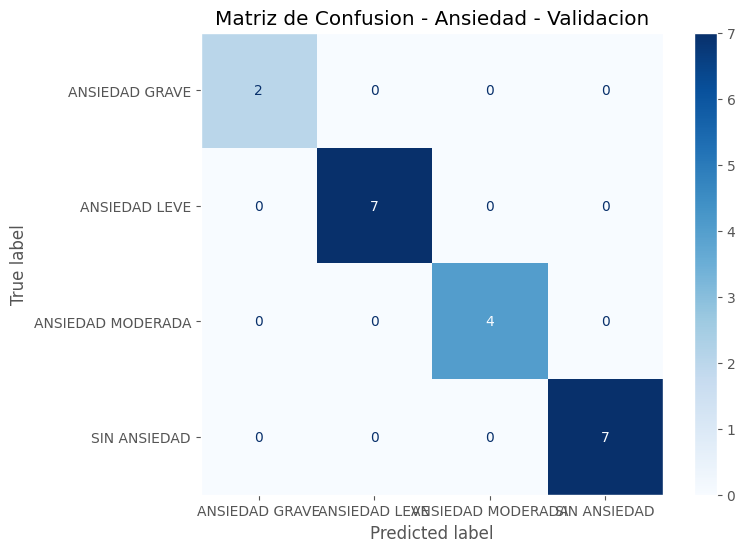


--- Reporte de Clasificacion (Ansiedad - Test) ---
                   precision    recall  f1-score   support

   ANSIEDAD GRAVE       0.00      0.00      0.00         1
    ANSIEDAD LEVE       1.00      1.00      1.00         7
ANSIEDAD MODERADA       0.83      1.00      0.91         5
     SIN ANSIEDAD       1.00      1.00      1.00         8

         accuracy                           0.95        21
        macro avg       0.71      0.75      0.73        21
     weighted avg       0.91      0.95      0.93        21



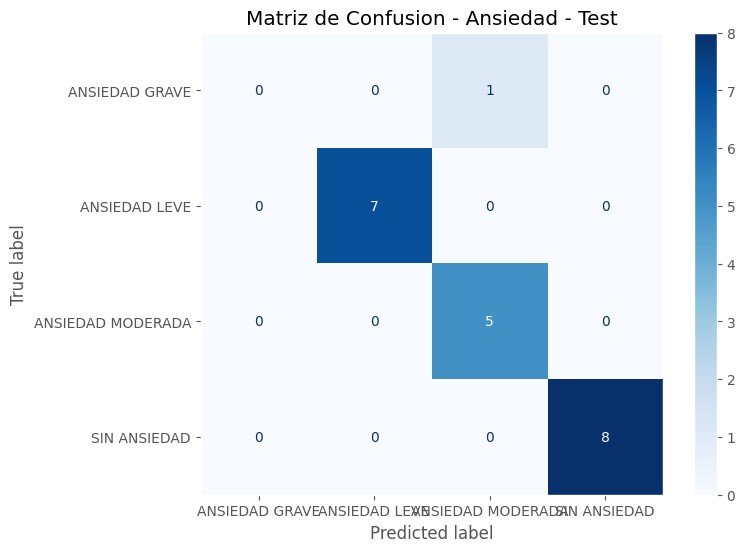

In [ ]:
# Evaluar en validacion para seleccion final (SIN USAR TEST)
best_model_ans = grid_ans.best_estimator_
y_val_pred_ans = best_model_ans.predict(X_val_ans)
report_split_metrics('Ansiedad - Validacion', y_val_ans, y_val_pred_ans, best_model_ans.classes_, 'Blues')

# Reentrenar en train+val antes de evaluar en test
X_trainval_ans = np.concatenate([X_train_ans, X_val_ans])
y_trainval_ans = np.concatenate([y_train_ans, y_val_ans])
best_model_ans.fit(X_trainval_ans, y_trainval_ans)

# Evaluar una sola vez en test
y_test_pred_ans = best_model_ans.predict(X_test_ans)
report_split_metrics('Ansiedad - Test', y_test_ans, y_test_pred_ans, best_model_ans.classes_, 'Blues')

In [ ]:
# Guardar el pipeline entrenado final
model_path_ans = 'rl_model_ansiedad.joblib'
joblib.dump(best_model_ans, model_path_ans)
print(f"Modelo de Ansiedad guardado exitosamente en '{model_path_ans}'")

Modelo de Ansiedad guardado exitosamente en 'rl_model_ansiedad.joblib'


## 3. Modelo de Predicción de Estrés (Support Vector Machine - SVM)

Cargamos los datos de `Data_estres.xlsx`, exploramos su distribución y entrenamos un clasificador SVM con optimización de parámetros (`C`, `kernel`, `gamma`).

Dimensiones del dataset de Estrés: (204, 12)
Valores nulos en el dataset: 0

Distribución de Clases (Nivel de Estrés):
NIVEL_ESTRES
ESTRES_BAJO     99
ESTRES_MEDIO    73
SIN_ESTRES      17
ESTRES_ALTO     15
Name: count, dtype: int64


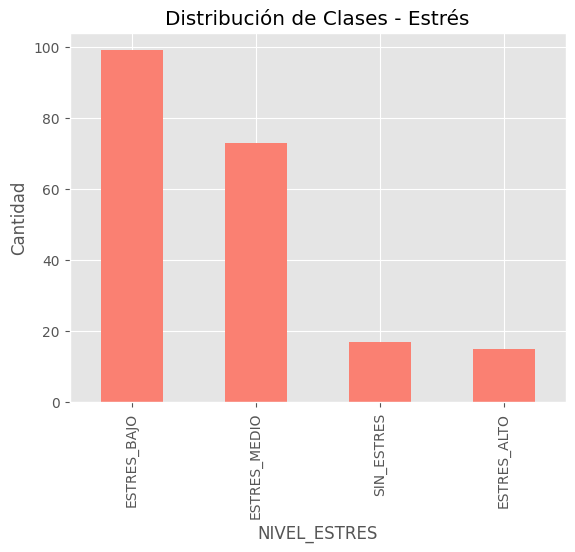

In [27]:
# Cargar datos de estrés
data_est = pd.read_excel('Data_estres.xlsx')
print(f"Dimensiones del dataset de Estrés: {data_est.shape}")
print(f"Valores nulos en el dataset: {data_est.isnull().sum().sum()}")

# Distribución del nivel de estrés
print("\nDistribución de Clases (Nivel de Estrés):")
print(data_est['NIVEL_ESTRES'].value_counts())
data_est['NIVEL_ESTRES'].value_counts().plot(kind='bar', color='salmon')
plt.title('Distribución de Clases - Estrés')
plt.ylabel('Cantidad')
plt.show()

In [28]:
# Preparacion de datos
# Usamos las 6 preguntas clinicas (P_E1 a P_E6)
# Convertimos a numpy standard usando .to_numpy() para evitar incompatibilidades con arrays Arrow
X_est = data_est[['P_E1','P_E2','P_E3','P_E4','P_E5','P_E6']].to_numpy()
y_est = data_est['NIVEL_ESTRES'].to_numpy(dtype=str)

# Particion train/val/test estratificada: 80/10/10
X_train_est, X_val_est, X_test_est, y_train_est, y_val_est, y_test_est = split_train_val_test(
    X_est, y_est, train_size=0.8, val_size=0.1, test_size=0.1, random_state=3
 )

print(f"Entrenamiento: {X_train_est.shape}, Validacion: {X_val_est.shape}, Prueba: {X_test_est.shape}")

# Pipeline que encapsula StandardScaler y SVM (los clasificadores SVM son sensibles a escalas)
pipeline_est = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(probability=True, random_state=42))
])

# Rejilla de busqueda de hiperparametros para regularizacion y kernel de SVM
param_grid_est = {
    'classifier__C': [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'classifier__kernel': ['linear', 'rbf', 'sigmoid'],
    'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
}

# Validacion cruzada estratificada (5 folds)
cv_est = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search SOLO en train
grid_est = GridSearchCV(
    pipeline_est, param_grid_est, cv=cv_est, scoring='accuracy', n_jobs=-1, return_train_score=True
 )
grid_est.fit(X_train_est, y_train_est)

print(f"Mejores hiperparametros para Estres: {grid_est.best_params_}")
print(f"Precision promedio en CV (train): {grid_est.best_score_:.4f}")
print(f"Precision promedio en train (fit): {grid_est.cv_results_['mean_train_score'][grid_est.best_index_]:.4f}")

Entrenamiento: (163, 6), Validacion: (20, 6), Prueba: (21, 6)
Mejores hiperparametros para Estres: {'classifier__C': 5.0, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Precision promedio en CV (train): 0.9879
Precision promedio en train (fit): 1.0000



--- Reporte de Clasificacion (Estres - Validacion) ---
              precision    recall  f1-score   support

 ESTRES_ALTO       1.00      1.00      1.00         1
 ESTRES_BAJO       1.00      1.00      1.00        10
ESTRES_MEDIO       1.00      1.00      1.00         7
  SIN_ESTRES       1.00      1.00      1.00         2

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



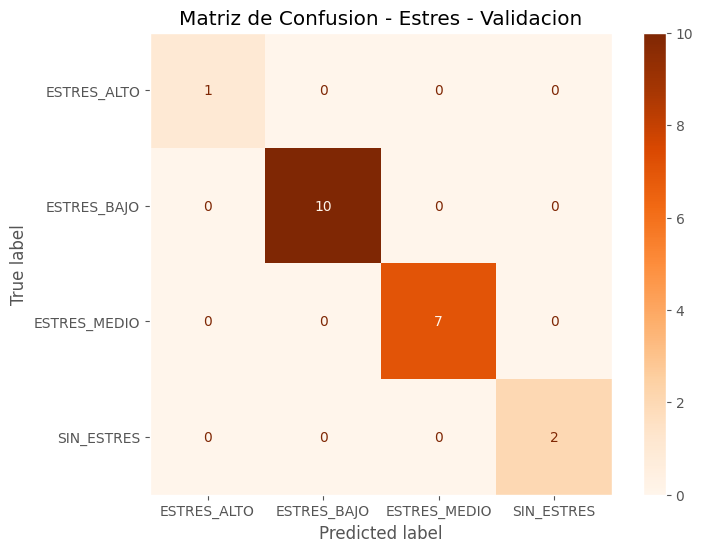


--- Reporte de Clasificacion (Estres - Test) ---
              precision    recall  f1-score   support

 ESTRES_ALTO       1.00      1.00      1.00         2
 ESTRES_BAJO       1.00      1.00      1.00        10
ESTRES_MEDIO       1.00      1.00      1.00         8
  SIN_ESTRES       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



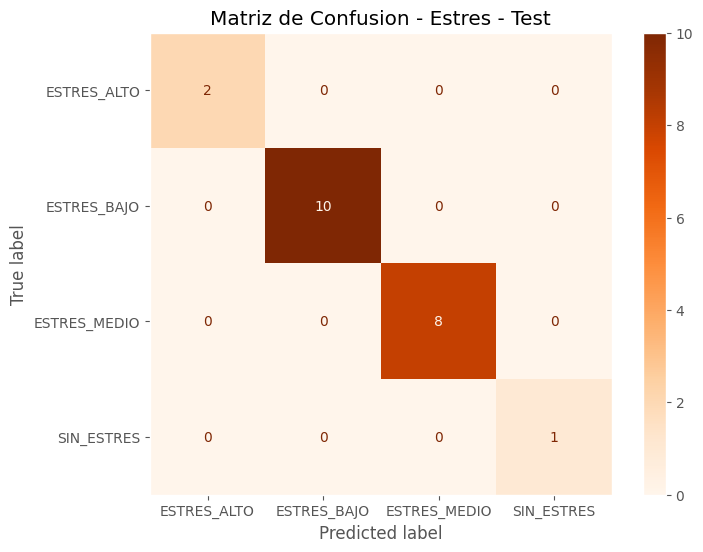

In [ ]:
# Evaluar en validacion para seleccion final (SIN USAR TEST)
best_model_est = grid_est.best_estimator_
y_val_pred_est = best_model_est.predict(X_val_est)
report_split_metrics('Estres - Validacion', y_val_est, y_val_pred_est, best_model_est.classes_, 'Oranges')

# Reentrenar en train+val antes de evaluar en test
X_trainval_est = np.concatenate([X_train_est, X_val_est])
y_trainval_est = np.concatenate([y_train_est, y_val_est])
best_model_est.fit(X_trainval_est, y_trainval_est)

# Evaluar una sola vez en test
y_test_pred_est = best_model_est.predict(X_test_est)
report_split_metrics('Estres - Test', y_test_est, y_test_pred_est, best_model_est.classes_, 'Oranges')

In [ ]:
# Guardar el pipeline entrenado final
model_path_est = 'svm_classifier_stress.joblib'
joblib.dump(best_model_est, model_path_est)
print(f"Modelo de Estres guardado exitosamente en '{model_path_est}'")

Modelo de Estres guardado exitosamente en 'svm_classifier_stress.joblib'
